In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df1=pd.read_csv(r"C:\\Users\\TECHNO ZONE\\Downloads\\workspace (4)\\workspace\\data\\flights.csv")
df2=pd.read_csv(r"C:\\Users\\TECHNO ZONE\\Downloads\\workspace (4)\\workspace\\data\\airlines_carrier_codes.csv")

In [4]:
df1

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute
0,0,2023,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15
1,1,2023,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29
2,2,2023,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40
3,3,2023,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45
4,4,2023,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,336771,2023,9,30,NaN,1455,NaN,NaN,1634,NaN,9E,3393,NaN,JFK,DCA,NaN,213,14,55
336772,336772,2023,9,30,NaN,2200,NaN,NaN,2312,NaN,9E,3525,NaN,LGA,SYR,NaN,198,22,0
336773,336773,2023,9,30,NaN,1210,NaN,NaN,1330,NaN,MQ,3461,N535MQ,LGA,BNA,NaN,764,12,10
336774,336774,2023,9,30,NaN,1159,NaN,NaN,1344,NaN,MQ,3572,N511MQ,LGA,CLE,NaN,419,11,59


In [5]:
df2.columns

Index(['Carrier Code', 'Airline Name'], dtype='object')

In [6]:
df1.isna().sum()

id                   0
year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
dtype: int64

In [7]:

df1['dep_delay']=df1['dep_delay'].fillna(0)
df1['arr_delay']=df1['arr_delay'].fillna(0)
df1['tailnum']=df1['tailnum'].fillna('unknown')



In [8]:
df1.dropna(inplace=True)

In [9]:
df2.isna().sum()

Carrier Code    0
Airline Name    0
dtype: int64

In [10]:
df2.columns

Index(['Carrier Code', 'Airline Name'], dtype='object')

In [11]:
df1.columns

Index(['id', 'year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute'],
      dtype='object')

In [12]:
df2


,Carrier Code,Airline Name
0,UA,United Airlines Inc.
1,AA,American Airlines Inc.
2,B6,JetBlue Airways
3,DL,Delta Air Lines Inc.
4,EV,ExpressJet Airlines Inc.
5,MQ,Envoy Air
6,US,US Airways Inc.
7,WN,Southwest Airlines Co.
8,VX,Virgin America
9,FL,AirTran Airways Corporation


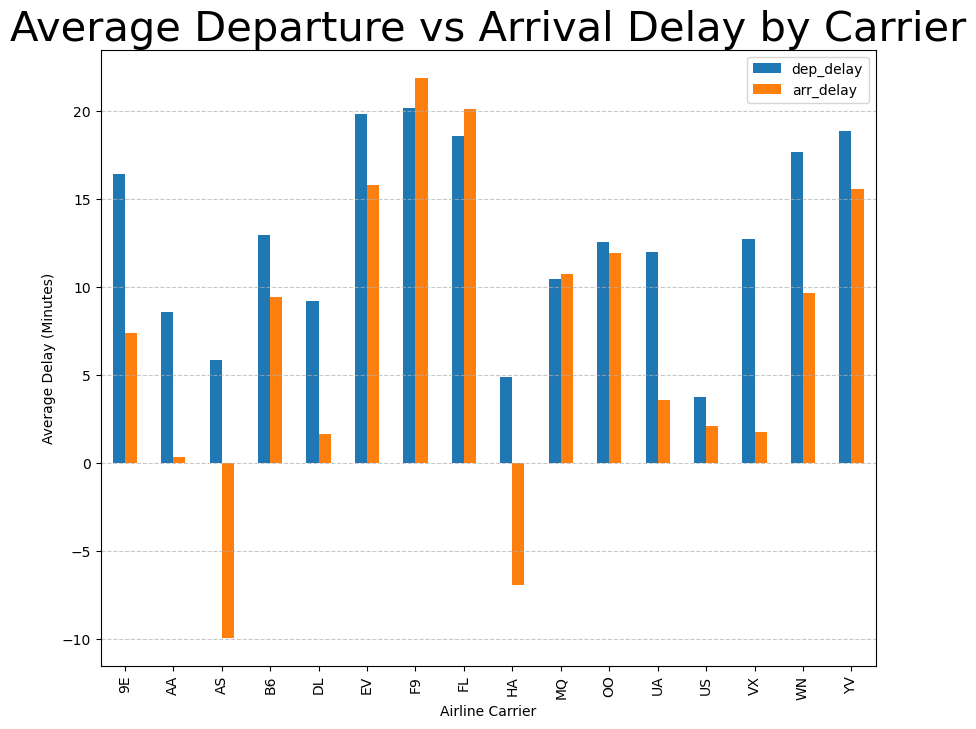

In [13]:
df1.groupby('carrier')[['dep_delay','arr_delay']].mean().plot(kind='bar',figsize=(10,8))
plt.title("Average Departure vs Arrival Delay by Carrier",fontsize=30,fontweight=16)
plt.xlabel("Airline Carrier")
plt.ylabel("Average Delay (Minutes)")
plt.grid(axis="y",linestyle='--',alpha=.7)
plt.show()

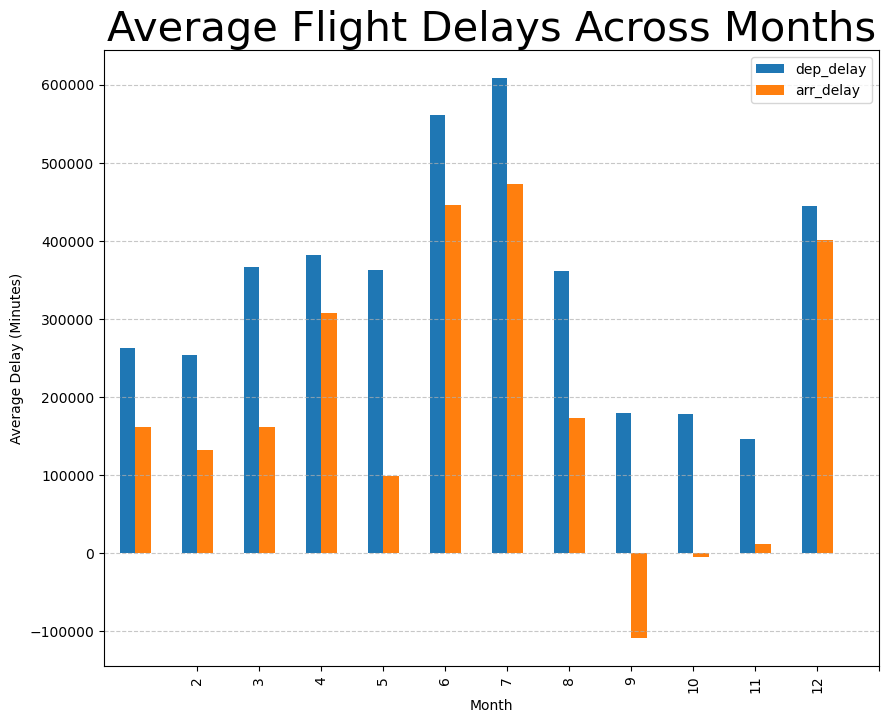

In [14]:
df1.groupby('month')[['dep_delay','arr_delay']].sum().plot(kind='bar',figsize=(10,8))
plt.title("Average Flight Delays Across Months",fontsize=30,fontweight=16)
plt.xlabel("Month")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(range(1, 13))
plt.grid(axis="y",linestyle="--",alpha=.7)
plt.show()

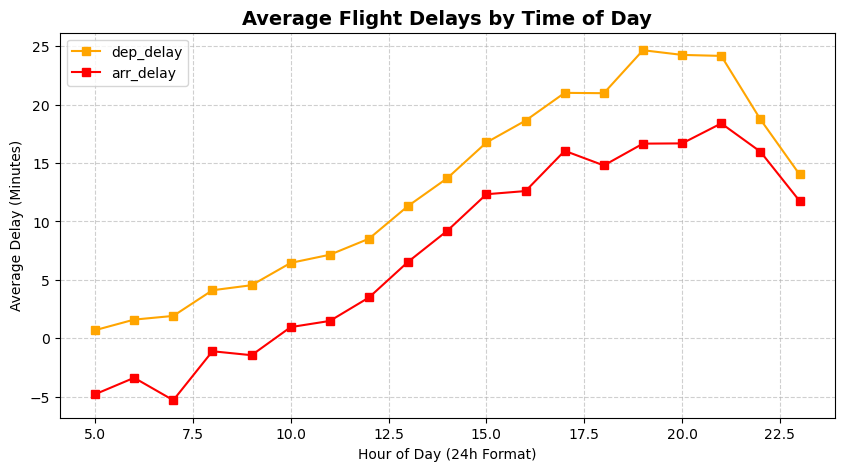

In [15]:
hourly_delay = df1.groupby('hour')[['dep_delay', 'arr_delay']].mean()
hourly_delay.plot(kind='line', marker='s', color=['orange', 'red'], figsize=(10, 5))
plt.title("Average Flight Delays by Time of Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day (24h Format)")
plt.ylabel("Average Delay (Minutes)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
df1.columns

Index(['id', 'year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute'],
      dtype='object')

C:\Users\TECHNO ZONE\AppData\Local\Temp\ipykernel_13132\3288705166.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="origin", y="Avg_Departure_Delay", data=airport_perf, palette='coolwarm')


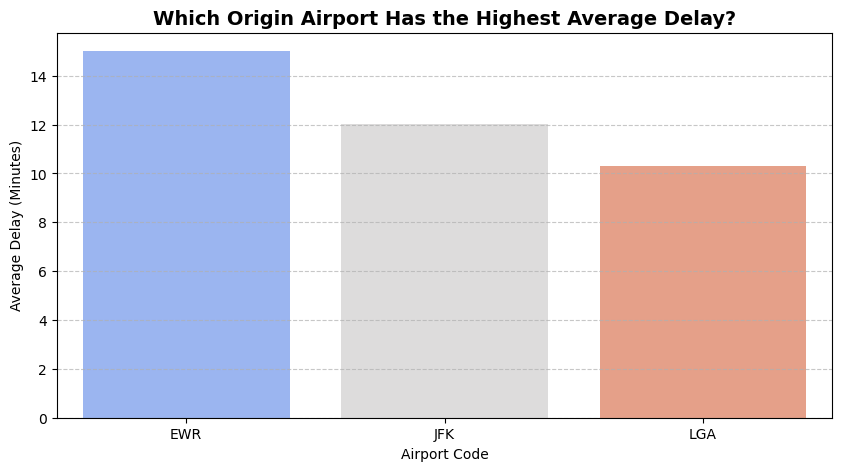

In [17]:

airport_perf = df1.groupby('origin').agg(
    Avg_Departure_Delay=('dep_delay', 'mean'),
    Total_Flights=('flight', 'count')
).reset_index() 
plt.figure(figsize=(10, 5))
sns.barplot(x="origin", y="Avg_Departure_Delay", data=airport_perf, palette='coolwarm')
plt.title("Which Origin Airport Has the Highest Average Delay?", fontsize=14, fontweight='bold')
plt.xlabel("Airport Code")
plt.ylabel("Average Delay (Minutes)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


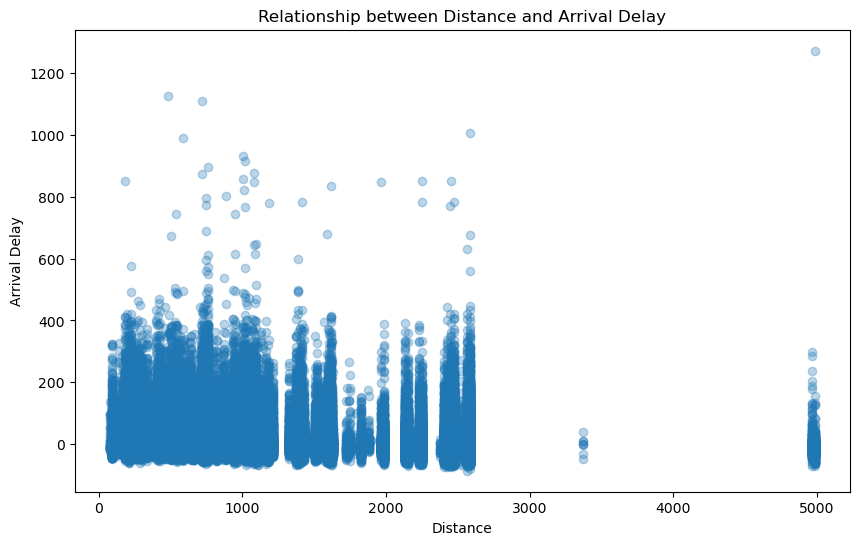

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(df1['distance'], df1['arr_delay'], alpha=0.3)

plt.xlabel("Distance")
plt.ylabel("Arrival Delay")
plt.title("Relationship between Distance and Arrival Delay")

plt.show()